## This notebook is based on the Spark training delivered by CERN IT
Contact: Luca.Canali@cern.ch

## Examples datasets
The following examples use sample data provided in the repository.  
We will use the movielens dataset from Kaggle, credits: https://www.kaggle.com/grouplens/movielens-20m-dataset

## Set up up the Spark master

- "local" for local execution
- "local[*]" for local execution using all core
- "spark://spark-master:7077" to connect to the Spark master running on the docker container

In [1]:
master = "spark://spark-master:7077"
dataFolder = "/data/lab02/" if master == "spark://spark-master:7077" else "../data/"

In [2]:
# Create Spark Session, you need this to work with Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder \
        .appName("Movies")  \
        .master(master) \
        .config("spark.driver.memory","8g") \
        .config("spark.ui.showConsoleProgress", "false") \
        .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 10:58:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# movielens dataset
# cache the tables, to improve the performance of the rest of the queries in the notebook
movies = spark.read.option("header","true").option("inferSchema", "true").csv(dataFolder + "movies.csv.gz").cache()

In [4]:
movies.show(5)
movies.printSchema()

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



In [5]:
# tags dataset
tags = spark.read.option("header","true").option("inferSchema", "true").csv(dataFolder + "tags.csv.gz").cache()

# ratings1 dataset. you may use both if you want
ratings = spark.read.option("header","true").option("inferSchema", "true").csv(dataFolder + "ratings1.csv.gz").cache()



In [6]:
# print schemas
tags.printSchema()
ratings.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)



### Count the number of entries of each table


In [7]:
# Print the number of entries of each table
print(f"Movies: {movies.count()}" )
print(f"Tags: {tags.count()}" )
print(f"Ratings: {ratings.count()}" )

Movies: 45843
Tags: 753170
Ratings: 13012144


### SQL Queries on the loaded tables
#### 1) How many movies produced per year?

In [8]:
# Add the column Year to "movies".
# To extract the year use substring or regexp_extract
from pyspark.sql import functions as sf

movies2 = movies.withColumn("Year", sf.regexp_extract(movies.title, r".* \((\d+)\)", 1))
movies2.show()

+-------+--------------------+--------------------+----+
|movieId|               title|              genres|Year|
+-------+--------------------+--------------------+----+
|      1|    Toy Story (1995)|Adventure|Animati...|1995|
|      2|      Jumanji (1995)|Adventure|Childre...|1995|
|      3|Grumpier Old Men ...|      Comedy|Romance|1995|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|1995|
|      5|Father of the Bri...|              Comedy|1995|
|      6|         Heat (1995)|Action|Crime|Thri...|1995|
|      7|      Sabrina (1995)|      Comedy|Romance|1995|
|      8| Tom and Huck (1995)|  Adventure|Children|1995|
|      9| Sudden Death (1995)|              Action|1995|
|     10|    GoldenEye (1995)|Action|Adventure|...|1995|
|     11|American Presiden...|Comedy|Drama|Romance|1995|
|     12|Dracula: Dead and...|       Comedy|Horror|1995|
|     13|        Balto (1995)|Adventure|Animati...|1995|
|     14|        Nixon (1995)|               Drama|1995|
|     15|Cutthroat Island ...|A

In [9]:
# number of movies per year

movies2.groupBy("year").count().show()

+----+-----+
|year|count|
+----+-----+
|1953|  207|
|1903|   18|
|1957|  246|
|1897|    8|
|1987|  464|
|1956|  214|
|1936|  148|
|2016| 1593|
|2012| 1752|
|1958|  219|
|1910|    7|
|1943|  144|
|1915|   29|
|1972|  382|
|1931|  101|
|1988|  469|
|1938|  130|
|1926|   51|
|1911|    6|
|1918|   15|
+----+-----+
only showing top 20 rows


In [10]:
# if you want you may use this code to plot your statistic
# convert your dataframe to pandas and place it in variable m_yr

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
m_yr = movies2.groupBy("year").count().toPandas()

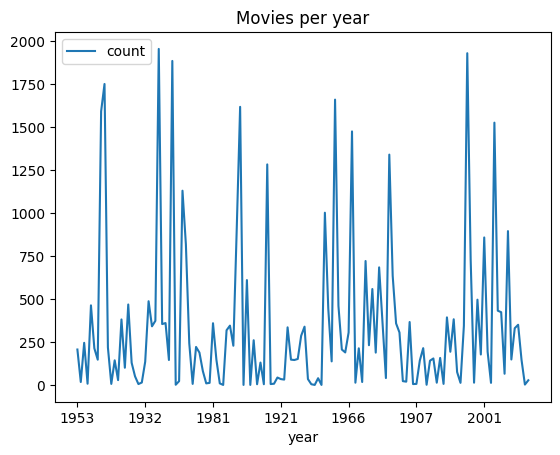

In [11]:
m_yr.plot(x='year',y='count',kind='line', title='Movies per year');

#### 2) Top movies by number of ratings

In [12]:
# Find the highest rated movies.
# Use a join

ratings.groupBy("movieId").count().join(movies, "movieId").sort(
    "count", ascending=False
).select("title", "count").show()

+--------------------+-----+
|               title|count|
+--------------------+-----+
| Forrest Gump (1994)|45782|
|Shawshank Redempt...|45546|
| Pulp Fiction (1994)|43755|
|Silence of the La...|41807|
|  Matrix, The (1999)|38860|
|Star Wars: Episod...|38414|
|Jurassic Park (1993)|37163|
|Schindler's List ...|33780|
|   Braveheart (1995)|33153|
|    Toy Story (1995)|32961|
|Star Wars: Episod...|31311|
|Terminator 2: Jud...|30890|
|Star Wars: Episod...|30767|
|   Fight Club (1999)|29931|
|Raiders of the Lo...|29829|
|Usual Suspects, T...|29635|
|American Beauty (...|28796|
|    Apollo 13 (1995)|28700|
|Godfather, The (1...|28582|
|Independence Day ...|28515|
+--------------------+-----+
only showing top 20 rows


#### 3) Highly rated movies
Find the top 5 highly rated movies

In [13]:
ratings.groupBy(ratings.movieId).avg("rating").join(movies, "movieId").select(
    "title", "avg(rating)"
).sort("avg(rating)", ascending=False).show()

+--------------------+-----------+
|               title|avg(rating)|
+--------------------+-----------+
|Silver Stallion (...|        5.0|
| Bed of Roses (1933)|        5.0|
|      The Box (2004)|        5.0|
|Going Attractions...|        5.0|
|Keeping the Promi...|        5.0|
|Mobile Suit Gunda...|        5.0|
|A Letter for Evie...|        5.0|
|Placebo: Soulmate...|        5.0|
|Beyoncé: Life Is ...|        5.0|
|Ninja Bachelor Pa...|        5.0|
|Sign Painters (2014)|        5.0|
|Who Killed Chea V...|        5.0|
|Charley and the A...|        5.0|
| Four Mothers (1941)|        5.0|
|    Go Figure (2005)|        5.0|
|       1. Mai (2008)|        5.0|
|Robin Williams - ...|        5.0|
|     Clearcut (1991)|        5.0|
|Out on a Limb (1987)|        5.0|
|Twisted Seduction...|        5.0|
+--------------------+-----------+
only showing top 20 rows


#### Drill down on the top entries:
   - How many reviews contributed to this rating?

Lets only take in account movies that have more than 100 reviews

In [14]:
ratings.groupBy(ratings.movieId).avg("rating").join(movies, "movieId").join(
    ratings.groupBy("movieId").count().filter("count > 100"), "movieId"
).sort("avg(rating)", ascending=False).show()

+-------+------------------+--------------------+--------------------+-----+
|movieId|       avg(rating)|               title|              genres|count|
+-------+------------------+--------------------+--------------------+-----+
| 159817| 4.467391304347826| Planet Earth (2006)|         Documentary|  368|
| 170705| 4.431654676258993|Band of Brothers ...|    Action|Drama|War|  139|
|    318| 4.426338207526457|Shawshank Redempt...|         Crime|Drama|45546|
|    858| 4.335648310125253|Godfather, The (1...|         Crime|Drama|28582|
|     50| 4.299493841741184|Usual Suspects, T...|Crime|Mystery|Thr...|29635|
|   1221|4.2667176155903705|Godfather: Part I...|         Crime|Drama|18319|
|   2019| 4.265507246376812|Seven Samurai (Sh...|Action|Adventure|...| 6900|
|    527| 4.261944937833038|Schindler's List ...|           Drama|War|33780|
| 142115| 4.234615384615385|The Blue Planet (...|         Documentary|  130|
|   2959| 4.232033677458154|   Fight Club (1999)|Action|Crime|Dram...|29931|

#### 4) Find the top rated movie of every year since 2000

In [17]:
# End the Spark application

from pyspark.sql.types import IntegerType

intmovies = movies2.withColumn("year", movies2["year"].try_cast(IntegerType()))
intmovies.printSchema()

ratings.groupBy("movieId").avg("rating").join(intmovies, "movieId").sort(
    "avg(rating)", ascending=False
).filter("year > 2000").show()

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- year: integer (nullable = true)

+-------+-----------+--------------------+--------------------+----+
|movieId|avg(rating)|               title|              genres|year|
+-------+-----------+--------------------+--------------------+----+
| 175731|        5.0|      The Box (2004)|              Comedy|2004|
| 133543|        5.0| Manos sucias (2014)|      Drama|Thriller|2014|
| 143422|        5.0|            2 (2007)|               Drama|2007|
| 159471|        5.0|Evening's Civil T...|  (no genres listed)|2008|
| 135639|        5.0|Come Dance at My ...|               Drama|2009|
| 151367|        5.0|Twisted Seduction...|Comedy|Romance|Th...|2010|
| 149879|        5.0| Aschenputtel (2010)|    Children|Fantasy|2010|
| 167196|        5.0|       1. Mai (2008)|               Drama|2008|
|  56102|        5.0|Endgame: Blueprin...|         Documentary|2007|
| 164278|     